In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
import pandas as pd

In [3]:
from CustomTree.customTree import CustomDecisionTree
from CustomTree.decisionTreeToCustomTreeParser import sklearn_tree_to_custom_tree, copy_custom_tree
# from CustomTree.graphicallyShowingTree import visualize_custom_tree #, plot_tree_partitions, plot_tree_partitions_2d_rectangles
from CustomTree.quadratic_constraint_optimization import gurobi_minimax, predict_with_minmax_model
from CustomTree.custom_tree_pruning import global_greedy_prune, global_greedy_prune_with_custom_cost, get_custom_cost_function

In [4]:
from Visualization.graphicallyShowingTree import visualize_custom_tree
from Visualization.partition_plot_matplotlib import plot_tree_partitions, plot_tree_partitions_2d_rectangles
from Visualization.partition_plot_matplotlib import plot_tree_partitions_3d_scatter, plot_tree_partitions_3d_cubes
from Visualization.partition_plot_plotly import plot_tree_partitions_plotly

In [5]:
from CustomTree.evaluationMethods import normalized_root_mean_square_error, mean_absolute_error

In [25]:

# dataset_paths = {
#     "Jet" : r'/Users/khalilulrehman/Academic/Phd Italy 2023_26/University of LAquila/Research Papers tasks/Benchmarks_Systems/Robust Control for Dynamical Systems With Non-Gaussian Noise via Formal Abstractions/Neural-Abstractions-V2/Dataset/jet/jet_10000/data_jet_10000.csv',
#     "Exponential": r'/Users/khalilulrehman/Academic/Phd Italy 2023_26/University of LAquila/Research Papers tasks/Benchmarks_Systems/Robust Control for Dynamical Systems With Non-Gaussian Noise via Formal Abstractions/Neural-Abstractions-V2/Dataset/exp/exp_10000/data_exp_10000.csv',
#     "NL1": r'/Users/khalilulrehman/Academic/Phd Italy 2023_26/University of LAquila/Research Papers tasks/Benchmarks_Systems/Robust Control for Dynamical Systems With Non-Gaussian Noise via Formal Abstractions/Neural-Abstractions-V2/Dataset/nl1/nl1_10000/data_nl1_10000.csv',
#     "NL2": r'/Users/khalilulrehman/Academic/Phd Italy 2023_26/University of LAquila/Research Papers tasks/Benchmarks_Systems/Robust Control for Dynamical Systems With Non-Gaussian Noise via Formal Abstractions/Neural-Abstractions-V2/Dataset/nl2/nl2_10000/data_nl2_10000.csv',
#     "Tank": r'/Users/khalilulrehman/Academic/Phd Italy 2023_26/University of LAquila/Research Papers tasks/Benchmarks_Systems/Robust Control for Dynamical Systems With Non-Gaussian Noise via Formal Abstractions/Neural-Abstractions-V2/Dataset/tank/tank_10000/data_tank_10000.csv',
#     "Steam" : r'/Users/khalilulrehman/Academic/Phd Italy 2023_26/University of LAquila/Research Papers tasks/Benchmarks_Systems/Robust Control for Dynamical Systems With Non-Gaussian Noise via Formal Abstractions/Neural-Abstractions-V2/Dataset/steam/steam_10000/data_steam_10000.csv',
#     # "Navigation" : "/Users/khalilulrehman/Academic/Phd Italy 2023_26/University of LAquila/Research Papers tasks/RegressionTreeWithRefinment/RegressionTreeRefinment/data_files/RandV_1_RandPosition/navigation_trejectory_dataset.csv",
# }

dataset_paths = {
    "Jet" : r'datasets/data_jet_10000.csv',
    "Exponential": r'datasets/data_exp_10000.csv',
    "NL1": r'datasets/data_nl1_10000.csv',
    "NL2": r'datasets/data_nl2_10000.csv',
    "Tank": r'datasets/data_tank_10000.csv',
    # "Steam" : r'datasets/data_steam_10000.csv',
    
    # "Navigation" : "/Users/khalilulrehman/Academic/Phd Italy 2023_26/University of LAquila/Research Papers tasks/RegressionTreeWithRefinment/RegressionTreeRefinment/data_files/RandV_1_RandPosition/navigation_trejectory_dataset.csv",
}



# Systems Experiment

In [7]:

# Create a results list to accumulate all experiments
all_results = []

for system_name in dataset_paths:
    print(f"System Name = {system_name}")
    read_df = pd.read_csv(dataset_paths[system_name])
    read_df_dim = read_df.shape[1]
    X_attribute_count = int(read_df_dim/2)
    Y_class_count = int(read_df_dim/2)
    X_read = read_df.iloc[:, :X_attribute_count].values
    y_read = read_df.iloc[:, X_attribute_count:X_attribute_count + Y_class_count].values
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_read, y_read, test_size=0.3, random_state=42
    )
    
    max_depth_for_experiment = [ 4]# , 6, 8, 10, 15]
    for max_depth_item in max_depth_for_experiment:
        print(f"Max Depth = {max_depth_item}")
        dt_model_tree = DecisionTreeRegressor(
            max_depth= max_depth_item, 
            min_samples_leaf=1,
            random_state=42
        )
        
        dt_model_tree.fit(X_train, y_train)

        NRMSE_Train_Tree = normalized_root_mean_square_error(y_true=y_train, y_pred= dt_model_tree.predict(X_train))
        NRMSE_Test_Tree = normalized_root_mean_square_error(y_true=y_test, y_pred= dt_model_tree.predict(X_test))
        print(f"NRMSE Training using Tree = {NRMSE_Train_Tree}")
        print(f"NRMSE Testing using Tree = {NRMSE_Test_Tree}")


        print("Converting Decision Tree to Custom Tree")
        # Converting Decision Tree Regressor To Custom Tree
        custom_tree = sklearn_tree_to_custom_tree(dt_model_tree, X_train)
        print(f"Number of Nodes = {custom_tree.num_nodes()}\nNumber of Leaves = {custom_tree.num_leaves()}\nDepth of Tree = {custom_tree.compute_max_depth()}")
        print("Optimizing Original Leaves")
        for leaf in custom_tree.get_leaves():
            M_val, m0_val, h_val = gurobi_minimax(
                X_train[leaf.sample_indices],
                y_train[leaf.sample_indices],
            )
        
            leaf.h = h_val
            leaf.M = M_val
            leaf.M_0 = m0_val
        print("Evaluating The Affine Model Tree Before Pruning")
        NRMSE_Train_Affine_before = normalized_root_mean_square_error(y_true=y_train, y_pred= predict_with_minmax_model(custom_tree=custom_tree, X=X_train))
        NRMSE_Test_Affine_before = normalized_root_mean_square_error(y_true=y_test, y_pred= predict_with_minmax_model(custom_tree=custom_tree, X=X_test))
        print(f"NRMSE Training using Affine Before Pruning = {NRMSE_Train_Affine_before}")
        print(f"NRMSE Testing using Affine Before Pruning = {NRMSE_Test_Affine_before}")
        cost_functions = ["basic", "average"]
        alphas = [0.001, 0.01, 0.05, 0.1, 0.5]
        for cost_function_item in cost_functions:
            print(f"Cost Function = {cost_function_item}")
            for alpha in alphas:
                print(f"Selected alpha value = {alpha}")
                tree_copy = copy_custom_tree(custom_tree)
                cost_fn = get_custom_cost_function(alpha, cost_type=cost_function_item)
                print("BEFORE")
                nodes_before = tree_copy.num_nodes()
                print("nodes :", nodes_before)
                leaves_before = tree_copy.num_leaves()
                print("leaves:", leaves_before)
                depth_before = tree_copy.compute_max_depth()
                print("depth :", depth_before)
                global_greedy_prune_with_custom_cost(tree_copy, X_train, y_train, cost_fn, plot_tree_each_iteration=False, alpha = alpha, verbose=False)
                
                print("\nAFTER")
                nodes_after = tree_copy.num_nodes()
                print("nodes :", nodes_after)
                leaves_after = tree_copy.num_leaves()
                print("leaves:", leaves_after)
                depth_after = tree_copy.compute_max_depth()
                print("depth :", depth_after)
                NRMSE_Train_Affine_after = normalized_root_mean_square_error(y_true=y_train, y_pred= predict_with_minmax_model(custom_tree=tree_copy, X=X_train))
                NRMSE_Test_Affine_after = normalized_root_mean_square_error(y_true=y_test, y_pred= predict_with_minmax_model(custom_tree=tree_copy, X=X_test))
                print(f"NRMSE Training using Tree = {NRMSE_Train_Affine_after}")
                print(f"NRMSE Testing using Tree = {NRMSE_Test_Affine_after}")

                visualize_custom_tree(tree=tree_copy, save_path=f"graphs/trees/{system_name}/{max_depth_item}/{cost_function_item}/{system_name}-{alpha}.png")
                plot_tree_partitions_plotly(tree_copy, X_train, save_path=f"graphs/partitions/{system_name}/{max_depth_item}/{cost_function_item}/{system_name}-{alpha}.png")
                # Save results
                all_results.append({
                    "system_name": system_name,
                    "max_depth": max_depth_item,
                    "cost_function": cost_function_item,
                    "alpha": alpha,
                    "nodes_before": nodes_before,
                    "leaves_before": leaves_before,
                    "depth_before": depth_before,
                    "nodes_after": nodes_after,
                    "leaves_after": leaves_after,
                    "depth_after": depth_after,
                    "NRMSE_Train_Tree": NRMSE_Train_Tree,
                    "NRMSE_Test_Tree": NRMSE_Test_Tree,
                    "NRMSE_Train_Affine_before": NRMSE_Train_Affine_before,
                    "NRMSE_Test_Affine_before": NRMSE_Test_Affine_before,
                    "NRMSE_Train_Affine_after": NRMSE_Train_Affine_after,
                    "NRMSE_Test_Affine_after": NRMSE_Test_Affine_after
                })

# Save all results to CSV and JSON for future analysis
results_df = pd.DataFrame(all_results)
results_csv_path = "custom_tree_experiments_results.csv"
results_json_path = "custom_tree_experiments_results.json"

results_df.to_csv(results_csv_path, index=False)
results_df.to_json(results_json_path, orient="records", lines=True)

print(f"Results saved to {results_csv_path} and {results_json_path}")
                


NameError: name 'dataset_paths' is not defined

# Parallel Processing Code

In [15]:
import os
from concurrent.futures import ProcessPoolExecutor, as_completed

In [16]:
from pathlib import Path

def ensure_dir(path):
    Path(path).mkdir(parents=True, exist_ok=True)


In [21]:
def run_single_system(system_name, csv_path):

    print(f"==== Running system: {system_name} ====")

    results = []

    read_df = pd.read_csv(csv_path)
    read_df_dim = read_df.shape[1]

    X_attribute_count = int(read_df_dim / 2)
    Y_class_count = int(read_df_dim / 2)

    X_read = read_df.iloc[:, :X_attribute_count].values
    y_read = read_df.iloc[:, X_attribute_count:X_attribute_count + Y_class_count].values

    X_train, X_test, y_train, y_test = train_test_split(
        X_read, y_read, test_size=0.3, random_state=42
    )

    max_depth_for_experiment = [4, 6, 8, 10, 15]
    cost_functions = ["basic", "average"]
    alphas = [0.001, 0.01, 0.05, 0.1, 0.5]

    for max_depth_item in max_depth_for_experiment:

        dt_model_tree = DecisionTreeRegressor(
            max_depth=max_depth_item,
            min_samples_leaf=1,
            random_state=42,
        )

        dt_model_tree.fit(X_train, y_train)

        NRMSE_Train_Tree = normalized_root_mean_square_error(
            y_train, dt_model_tree.predict(X_train)
        )

        NRMSE_Test_Tree = normalized_root_mean_square_error(
            y_test, dt_model_tree.predict(X_test)
        )

        custom_tree = sklearn_tree_to_custom_tree(dt_model_tree, X_train)

        for leaf in custom_tree.get_leaves():
            M_val, m0_val, h_val = gurobi_minimax(
                X_train[leaf.sample_indices],
                y_train[leaf.sample_indices],
            )
            leaf.h = h_val
            leaf.M = M_val
            leaf.M_0 = m0_val

        # BEFORE pruning metrics
        NRMSE_Train_Affine_before = normalized_root_mean_square_error(
            y_train,
            predict_with_minmax_model(custom_tree, X_train),
        )

        NRMSE_Test_Affine_before = normalized_root_mean_square_error(
            y_test,
            predict_with_minmax_model(custom_tree, X_test),
        )

        for cost_function_item in cost_functions:
            for alpha in alphas:

                tree_copy = copy_custom_tree(custom_tree)
                cost_fn = get_custom_cost_function(alpha, cost_type=cost_function_item)

                nodes_before = tree_copy.num_nodes()
                leaves_before = tree_copy.num_leaves()
                depth_before = tree_copy.compute_max_depth()

                global_greedy_prune_with_custom_cost(
                    tree_copy,
                    X_train,
                    y_train,
                    cost_fn,
                    plot_tree_each_iteration=False,
                    alpha=alpha,
                    verbose=False,
                )

                nodes_after = tree_copy.num_nodes()
                leaves_after = tree_copy.num_leaves()
                depth_after = tree_copy.compute_max_depth()

                NRMSE_Train_Affine_after = normalized_root_mean_square_error(
                    y_train,
                    predict_with_minmax_model(tree_copy, X_train),
                )

                NRMSE_Test_Affine_after = normalized_root_mean_square_error(
                    y_test,
                    predict_with_minmax_model(tree_copy, X_test),
                )

                # -----------------------------
                # SAVE GRAPHS
                # -----------------------------

                tree_dir = f"graphs/trees/{system_name}/{max_depth_item}/{cost_function_item}"
                part_dir = f"graphs/partitions/{system_name}/{max_depth_item}/{cost_function_item}"

                ensure_dir(tree_dir)
                ensure_dir(part_dir)

                visualize_custom_tree(
                    tree=tree_copy,
                    save_path=f"{tree_dir}/{system_name}-{alpha}.png",
                )

                plot_tree_partitions_plotly(
                    tree_copy,
                    X_train,
                    save_path=f"{part_dir}/{system_name}-{alpha}.png",
                )

                # -----------------------------
                # RECORD RESULTS
                # -----------------------------

                results.append({
                    "system": system_name,
                    "max_depth": max_depth_item,
                    "cost_function": cost_function_item,
                    "alpha": alpha,

                    "nodes_before": nodes_before,
                    "leaves_before": leaves_before,
                    "depth_before": depth_before,

                    "nodes_after": nodes_after,
                    "leaves_after": leaves_after,
                    "depth_after": depth_after,

                    "NRMSE_tree_train": NRMSE_Train_Tree,
                    "NRMSE_tree_test": NRMSE_Test_Tree,

                    "NRMSE_affine_train_before": NRMSE_Train_Affine_before,
                    "NRMSE_affine_test_before": NRMSE_Test_Affine_before,

                    "NRMSE_affine_train_after": NRMSE_Train_Affine_after,
                    "NRMSE_affine_test_after": NRMSE_Test_Affine_after,
                })

    return results


In [23]:
all_results = []

with ProcessPoolExecutor(max_workers=os.cpu_count()) as executor:

    futures = {
        executor.submit(run_single_system, name, dataset_paths[name]): name
        for name in dataset_paths
    }

    for future in as_completed(futures):
        system_name = futures[future]

        try:
            system_results = future.result()
            all_results.extend(system_results)
            print(f"✔ Finished {system_name}")

        except Exception as e:
            print(f"❌ Failed {system_name}: {e}")

results_df = pd.DataFrame(all_results)

results_df.to_csv("parallel_tree_pruning_results.csv", index=False)
results_df.to_pickle("parallel_tree_pruning_results.pkl")

print("Saved results!")


# Parallel Processing with first 3 loops

In [26]:
from concurrent.futures import ProcessPoolExecutor, as_completed
import pandas as pd
import os

def run_single_experiment(args):

    (
        system_name,
        csv_path,
        max_depth_item,
        cost_function_item,
        alphas,
    ) = args

    local_results = []

    print(f"[START] {system_name} | depth={max_depth_item} | cost={cost_function_item}")

    read_df = pd.read_csv(csv_path)

    read_df_dim = read_df.shape[1]
    X_attribute_count = int(read_df_dim / 2)
    Y_class_count = int(read_df_dim / 2)

    X_read = read_df.iloc[:, :X_attribute_count].values
    y_read = read_df.iloc[:, X_attribute_count:X_attribute_count + Y_class_count].values

    X_train, X_test, y_train, y_test = train_test_split(
        X_read, y_read, test_size=0.3, random_state=42
    )

    dt_model_tree = DecisionTreeRegressor(
        max_depth=max_depth_item,
        min_samples_leaf=1,
        random_state=42
    )

    dt_model_tree.fit(X_train, y_train)

    NRMSE_Train_Tree = normalized_root_mean_square_error(
        y_train, dt_model_tree.predict(X_train)
    )
    NRMSE_Test_Tree = normalized_root_mean_square_error(
        y_test, dt_model_tree.predict(X_test)
    )

    custom_tree = sklearn_tree_to_custom_tree(dt_model_tree, X_train)

    # ---- optimize leaves ----
    for leaf in custom_tree.get_leaves():
        M_val, m0_val, h_val = gurobi_minimax(
            X_train[leaf.sample_indices],
            y_train[leaf.sample_indices],
        )
        leaf.h = h_val
        leaf.M = M_val
        leaf.M_0 = m0_val

    NRMSE_Train_Affine_before = normalized_root_mean_square_error(
        y_train, predict_with_minmax_model(custom_tree, X_train)
    )
    NRMSE_Test_Affine_before = normalized_root_mean_square_error(
        y_test, predict_with_minmax_model(custom_tree, X_test)
    )

    # -------------------------
    for alpha in alphas:

        tree_copy = copy_custom_tree(custom_tree)
        cost_fn = get_custom_cost_function(alpha, cost_type=cost_function_item)

        nodes_before = tree_copy.num_nodes()
        leaves_before = tree_copy.num_leaves()
        depth_before = tree_copy.compute_max_depth()

        global_greedy_prune_with_custom_cost(
            tree_copy,
            X_train,
            y_train,
            cost_fn,
            plot_tree_each_iteration=False,
            alpha=alpha,
            verbose=False
        )

        nodes_after = tree_copy.num_nodes()
        leaves_after = tree_copy.num_leaves()
        depth_after = tree_copy.compute_max_depth()

        NRMSE_Train_Affine_after = normalized_root_mean_square_error(
            y_train, predict_with_minmax_model(tree_copy, X_train)
        )
        NRMSE_Test_Affine_after = normalized_root_mean_square_error(
            y_test, predict_with_minmax_model(tree_copy, X_test)
        )

        # ----- SAVE FIGURES -----
        visualize_custom_tree(
            tree_copy,
            save_path=f"graphs/trees/{system_name}/{max_depth_item}/{cost_function_item}/{system_name}-{alpha}.png"
        )

        plot_tree_partitions_plotly(
            tree_copy,
            X_train,
            save_path=f"graphs/partitions/{system_name}/{max_depth_item}/{cost_function_item}/{system_name}-{alpha}.png"
        )

        local_results.append({
            "system_name": system_name,
            "max_depth": max_depth_item,
            "cost_function": cost_function_item,
            "alpha": alpha,

            "nodes_before": nodes_before,
            "leaves_before": leaves_before,
            "depth_before": depth_before,

            "nodes_after": nodes_after,
            "leaves_after": leaves_after,
            "depth_after": depth_after,

            "NRMSE_Train_Tree": NRMSE_Train_Tree,
            "NRMSE_Test_Tree": NRMSE_Test_Tree,

            "NRMSE_Train_Affine_before": NRMSE_Train_Affine_before,
            "NRMSE_Test_Affine_before": NRMSE_Test_Affine_before,

            "NRMSE_Train_Affine_after": NRMSE_Train_Affine_after,
            "NRMSE_Test_Affine_after": NRMSE_Test_Affine_after,
        })

    print(f"[DONE] {system_name} | depth={max_depth_item} | cost={cost_function_item}")

    return local_results


In [5]:
if __name__ == "__main__":

    max_depth_for_experiment = [4]
    cost_functions = ["basic", "average"]
    alphas = [0.001, 0.01, 0.05, 0.1, 0.5]

    tasks = []

    for system_name in dataset_paths:
        for max_depth_item in max_depth_for_experiment:
            for cost_function_item in cost_functions:

                tasks.append((
                    system_name,
                    dataset_paths[system_name],
                    max_depth_item,
                    cost_function_item,
                    alphas,
                ))

    all_results = []

    with ProcessPoolExecutor(max_workers=os.cpu_count() - 1) as executor:

        futures = [executor.submit(run_single_experiment, t) for t in tasks]

        for f in as_completed(futures):
            all_results.extend(f.result())

    # -------- SAVE RESULTS --------

    results_df = pd.DataFrame(all_results)

    results_df.to_csv("custom_tree_experiments_results.csv", index=False)
    results_df.to_json(
        "custom_tree_experiments_results.json",
        orient="records",
        lines=True
    )

    print("✅ All experiments finished and saved.")


NameError: name 'dataset_paths' is not defined

NameError: name 'plot_tree_partitions_2d_rectangles' is not defined

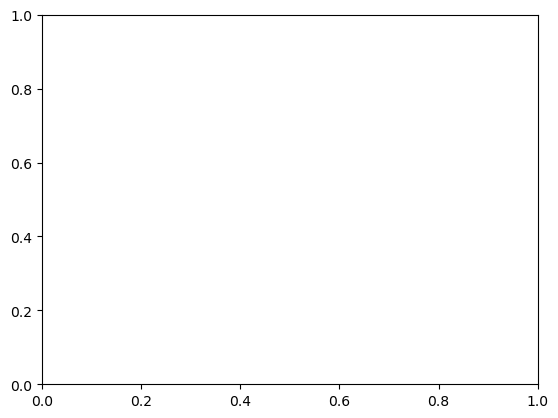

In [3]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
# plot_tree_partitions(custom_tree, X_train, ax=ax)
plot_tree_partitions_2d_rectangles(custom_tree, X_train, ax)
plt.show()
# plot_tree_partitions_plotly(custom_tree, X_train)


In [1]:
plot_tree_partitions_3d_cubes(custom_tree, X_train)


NameError: name 'plot_tree_partitions_3d_cubes' is not defined